In [1]:
#Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Importing Data

In [2]:

data = pd.read_csv('https://raw.githubusercontent.com/SagarChhabriya/data-science/refs/heads/main/datasets/TBD/Salary%20Data.csv')
data

,Experience Years,Salary
0,1.1,39343
1,1.2,42774
2,1.3,46205
3,1.5,37731
4,2.0,43525
5,2.2,39891
6,2.5,48266
7,2.9,56642
8,3.0,60150
9,3.2,54445


#Data Exploration

In [3]:
#Data Frame
data.head()

,Experience Years,Salary
0,1.1,39343
1,1.2,42774
2,1.3,46205
3,1.5,37731
4,2.0,43525


In [4]:
#Understanding the Dataset

data.shape

(40, 2)

In [5]:
data.dtypes

,0
Experience Years,float64
Salary,int64


In [6]:
data.describe()

,Experience Years,Salary
count,40.000000,40.000000
mean,5.152500,74743.625000
std,2.663715,25947.122885
min,1.100000,37731.000000
25%,3.200000,56878.250000
50%,4.600000,64472.500000
75%,6.875000,95023.250000
max,10.500000,122391.000000


In [7]:
#Checking Data Quality

data.isnull().sum()

,0
Experience Years,0
Salary,0


In [8]:
data.duplicated().sum()

np.int64(0)

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Experience Years  40 non-null     float64
 1   Salary            40 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 772.0 bytes


#Exploratory Visualization

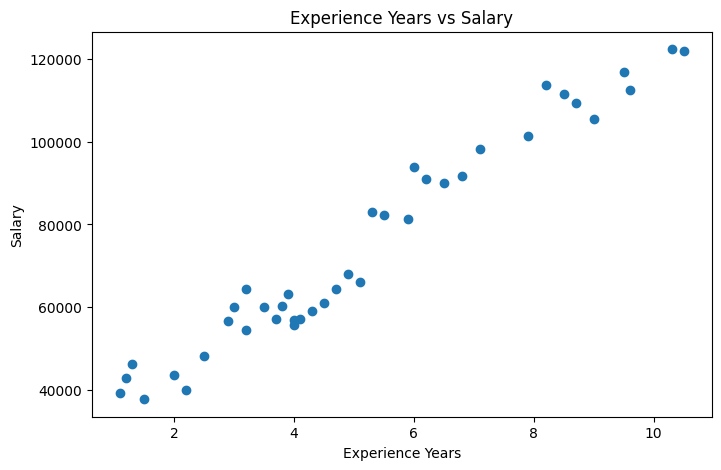

In [10]:
#Scatter Plot

plt.figure(figsize=(8, 5))
plt.scatter(data['Experience Years'], data['Salary'])
plt.xlabel('Experience Years')
plt.ylabel('Salary')
plt.title('Experience Years vs Salary')
plt.show()

In [11]:
#Correlation

data['Experience Years'].corr(data['Salary'])

np.float64(0.9776918968570496)

#Selecting X and y + train/test split

In [12]:
#Select Features and Target


X = data[['Experience Years']]
y = data['Salary']

In [13]:
#Spliting the Data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((32, 1), (8, 1), (32,), (8,))

In [15]:
#Training the Linear Regression Model

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [16]:
model.coef_, model.intercept_

(array([9408.03127251]), np.float64(26716.250176145535))

#Making Predictions

In [17]:
#Predict salaries for the test set

y_pred = model.predict(X_test)

In [18]:
#Compare actual vs predicted salaries

results = pd.DataFrame({
    'Actual Salary': y_test.values,
    'Predicted Salary': y_pred
})

results


,Actual Salary,Predicted Salary
0,61111,69052.390902
1,56957,64348.375266
2,55794,64348.375266
3,93940,83164.437811
4,43525,45532.312721
5,57189,61525.965884
6,112635,117033.350392
7,91000,85046.044066


#Evaluate the Model

In [19]:
#Calculating the metrics

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mse, rmse, mae, r2

(48077731.16919359,
 np.float64(6933.810724932834),
 6419.911069460598,
 0.9068577573647874)

In [20]:
#Displaying neatly

metrics = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'MAE', 'R² Score'],
    'Value': [mse, rmse, mae, r2]
})

metrics

,Metric,Value
0,MSE,4.807773e+07
1,RMSE,6.933811e+03
2,MAE,6.419911e+03
3,R² Score,9.068578e-01


#Visualizing the Regression Mode

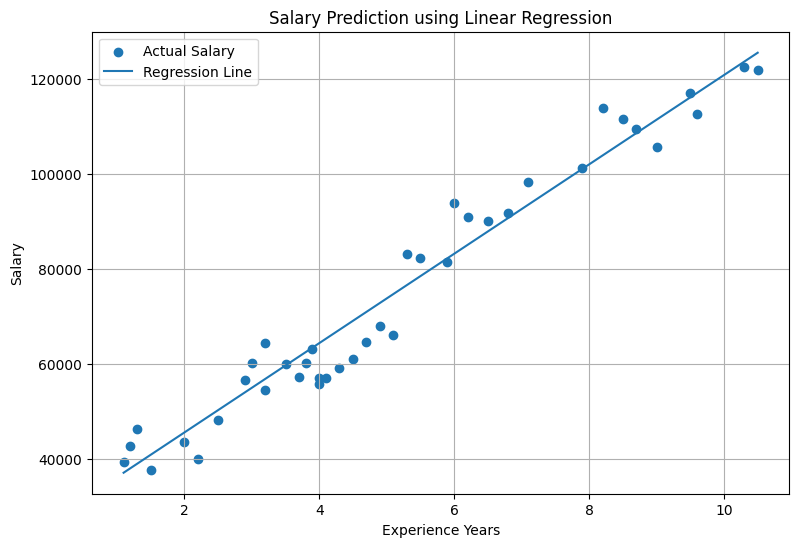

In [21]:
#Regression Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.scatter(X, y, label='Actual Salary')
plt.plot(X, model.predict(X), label='Regression Line')

plt.xlabel('Experience Years')
plt.ylabel('Salary')
plt.title('Salary Prediction using Linear Regression')
plt.legend()
plt.grid(True)

plt.show()

#Saving the Trained Model

In [22]:
import joblib

In [23]:
joblib.dump(model, 'salary_prediction_model.pkl')

['salary_prediction_model.pkl']

In [24]:
import os

os.path.exists('salary_prediction_model.pkl')

True

#Test Loading the Saved Model

In [25]:
loaded_model = joblib.load('salary_prediction_model.pkl')

In [26]:
#Testing a prediction

loaded_model.predict([[5]])

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([73756.40653868])

#Preparing the Project Files

In [27]:
#Creating the project folders

import os

os.makedirs('model', exist_ok=True)
os.makedirs('data', exist_ok=True)
os.makedirs('notebooks', exist_ok=True)


In [28]:
#Saving the model inside the model folder

joblib.dump(model, 'model/salary_prediction_model.pkl')

['model/salary_prediction_model.pkl']

In [29]:
os.path.exists('model/salary_prediction_model.pkl')

True

In [30]:
#Creating a Clean Prediction Test

test_input = pd.DataFrame({
    'Experience Years': [5]
})

loaded_model.predict(test_input)

array([73756.40653868])

#Saving the Dataset

In [31]:
data.to_csv('data/salary_dataset.csv', index=False)

In [32]:
os.path.exists('data/salary_dataset.csv')

True

#Creating the Streamlit Application

In [33]:
import os

os.makedirs('model', exist_ok=True)
os.makedirs('data', exist_ok=True)
os.makedirs('notebooks', exist_ok=True)

In [34]:
joblib.dump(model, 'model/salary_prediction_model.pkl')
os.path.exists('model/salary_prediction_model.pkl')

True

In [35]:
test_input = pd.DataFrame({
    'Experience Years': [5]
})

loaded_model.predict(test_input)

array([73756.40653868])

In [36]:
data.to_csv('data/salary_dataset.csv', index=False)
os.path.exists('data/salary_dataset.csv')

True

#Creating app.py

In [37]:
%%writefile app.py

import streamlit as st
import joblib
import pandas as pd

model = joblib.load('model/salary_prediction_model.pkl')

st.title('Salary Prediction App')

st.write(
    'Enter your years of experience to predict the expected salary.'
)

experience = st.number_input(
    'Experience Years',
    min_value=0.0,
    max_value=50.0,
    value=1.0,
    step=0.1
)

if st.button('Predict Salary'):
    input_data = pd.DataFrame({
        'Experience Years': [experience]
    })

    prediction = model.predict(input_data)[0]

    st.success(f'Predicted Salary: {prediction:,.2f}')

Writing app.py


In [38]:
os.path.exists('app.py')

True

#Installing Streamlit

In [39]:
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 36.7 MB/s eta 0:00:00


#Launching the Streamlit App

In [40]:
!streamlit run app.py &>/content/logs.txt &

import time
time.sleep(3)

!cat /content/logs.txt

In [41]:
#Check the Streamlit Server


!cat /content/logs.txt

#Creating requirements.txt

In [42]:
%%writefile requirements.txt

pandas
numpy
scikit-learn
joblib
streamlit
matplotlib

Writing requirements.txt


In [43]:
os.path.exists('requirements.txt')

True

#Creating .gitignore

In [44]:
%%writefile .gitignore

venv/
__pycache__/
*.pyc
.ipynb_checkpoints/
.env

Writing .gitignore


#Creating README.md

In [46]:
%%writefile README.md

# Salary Prediction using Machine Learning

## Project Description

This project develops an end-to-end Machine Learning application that predicts salary based on years of professional experience.

The project covers the complete Machine Learning workflow, including data exploration, preprocessing, model training, evaluation, model serialization, and deployment using Streamlit.

## Dataset

The dataset contains two variables:

- Experience Years
- Salary

The target variable is Salary, while Experience Years is used as the input feature.

## Model

Linear Regression

## Model Evaluation

The model was evaluated using:

- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Error (MAE)
- R² Score

### Results

- MSE: 48,077,731.17
- RMSE: 6,933.81
- MAE: 6,419.91
- R² Score: 0.9069

## Application

A Streamlit web application allows users to enter their years of experience and receive a predicted salary.

## Project Structure

ML_Project/

├── data/

│   └── salary_dataset.csv

├── model/

│   └── salary_prediction_model.pkl

├── notebooks/

│   └── model_training.ipynb

├── app.py

├── requirements.txt

├── README.md

└── .gitignore

## Author

Machine Learning Course Project

Writing README.md


In [47]:
os.path.exists('README.md')

True

In [48]:
#Verifying the complete project structure

import os

for root, dirs, files in os.walk('.'):
    level = root.replace('.', '').count(os.sep)
    indent = '    ' * level
    print(f'{indent}{os.path.basename(root)}/')
    for file in files:
        print(f'{indent}    {file}')

./
    salary_prediction_model.pkl
    README.md
    app.py
    requirements.txt
    .gitignore
    logs.txt
    .config/
        config_sentinel
        gce
        .last_opt_in_prompt.yaml
        .last_survey_prompt.yaml
        hidden_gcloud_config_universe_descriptor_data_cache_configs.db
        active_config
        default_configs.db
        .last_update_check.json
        logs/
            2026.09.16/
                13.26.04.283691.log
                13.26.17.091876.log
                13.26.29.139725.log
                13.26.30.459687.log
                13.26.15.129583.log
                13.25.37.877256.log
        configurations/
            config_default
    model/
        salary_prediction_model.pkl
    notebooks/
    data/
        salary_dataset.csv
    sample_data/
        README.md
        anscombe.json
        mnist_test.csv
        mnist_train_small.csv
        california_housing_test.csv
        california_housing_train.csv


In [49]:
import os
import shutil

os.makedirs('ML_Project/data', exist_ok=True)
os.makedirs('ML_Project/model', exist_ok=True)
os.makedirs('ML_Project/notebooks', exist_ok=True)

shutil.copy('data/salary_dataset.csv', 'ML_Project/data/salary_dataset.csv')
shutil.copy('model/salary_prediction_model.pkl', 'ML_Project/model/salary_prediction_model.pkl')
shutil.copy('app.py', 'ML_Project/app.py')
shutil.copy('requirements.txt', 'ML_Project/requirements.txt')
shutil.copy('README.md', 'ML_Project/README.md')
shutil.copy('.gitignore', 'ML_Project/.gitignore')

os.path.exists('ML_Project/data/salary_dataset.csv')

True